In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu

df = pd.read_csv("../data/customer_support_tickets.csv")

df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [3]:
print("Dimensões:", df.shape)
print("\nColunas:")
print(df.columns.tolist())

print("\nTipos:")
print(df.dtypes)

print("\nEstatísticas:")
display(df.describe(include="all").T)

Dimensões: (8469, 18)

Colunas:
['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating', 'Description Length']

Tipos:
Ticket ID                                int64
Customer Name                           object
Customer Email                          object
Customer Age                             int64
Customer Gender                         object
Product Purchased                       object
Date of Purchase                datetime64[ns]
Ticket Type                             object
Ticket Subject                          object
Ticket Description                      object
Ticket Status                           object
Resolution                              object
Ticket Priority                         object
Ti

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Ticket ID,8469.0,NaN,NaN,NaN,4235.0,1.0,2118.0,4235.0,6352.0,8469.0,2444.934048
Customer Name,8469,8028,Michael Garcia,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Email,8469,8320,bsmith@example.com,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Age,8469.0,NaN,NaN,NaN,44.026804,18.0,31.0,44.0,57.0,70.0,15.296112
Customer Gender,8469,3,Male,2896,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product Purchased,8469,42,Canon EOS,240,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date of Purchase,8469,NaN,NaN,NaN,2020-12-30 01:35:13.071201024,2020-01-01 00:00:00,2020-07-02 00:00:00,2020-12-31 00:00:00,2021-07-01 00:00:00,2021-12-30 00:00:00,NaN
Ticket Type,8469,5,Refund request,1752,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ticket Subject,8469,16,Refund request,576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ticket Description,8469,8077,I'm having an issue with the {product_purchase...,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
print("Valores ausentes:")
display(df.isnull().sum().sort_values(ascending=False))

print("Duplicados:", df.duplicated().sum())

print("\nValores únicos das categóricas:")
for col in df.select_dtypes("object"):
    print(f"\n{col}:")
    print(df[col].nunique(), "valores únicos")

Valores ausentes:


Customer Satisfaction Rating    5700
Time to Resolution              5700
Resolution                      5700
First Response Time             2819
Ticket ID                          0
Customer Name                      0
Ticket Channel                     0
Ticket Priority                    0
Ticket Status                      0
Ticket Description                 0
Ticket Subject                     0
Ticket Type                        0
Date of Purchase                   0
Product Purchased                  0
Customer Gender                    0
Customer Age                       0
Customer Email                     0
Description Length                 0
dtype: int64

Duplicados: 0

Valores únicos das categóricas:

Customer Name:
8028 valores únicos

Customer Email:
8320 valores únicos

Customer Gender:
3 valores únicos

Product Purchased:
42 valores únicos

Ticket Type:
5 valores únicos

Ticket Subject:
16 valores únicos

Ticket Description:
8077 valores únicos

Ticket Status:
3 valores únicos

Resolution:
2769 valores únicos

Ticket Priority:
4 valores únicos

Ticket Channel:
4 valores únicos

First Response Time:
5470 valores únicos

Time to Resolution:
2728 valores únicos


In [5]:
df["Date of Purchase"] = pd.to_datetime(
    df["Date of Purchase"],
    errors="coerce"
)

df["Description Length"] = df["Ticket Description"].str.len()

df_satisfaction = df.dropna(
    subset=["Customer Satisfaction Rating"]
).copy()

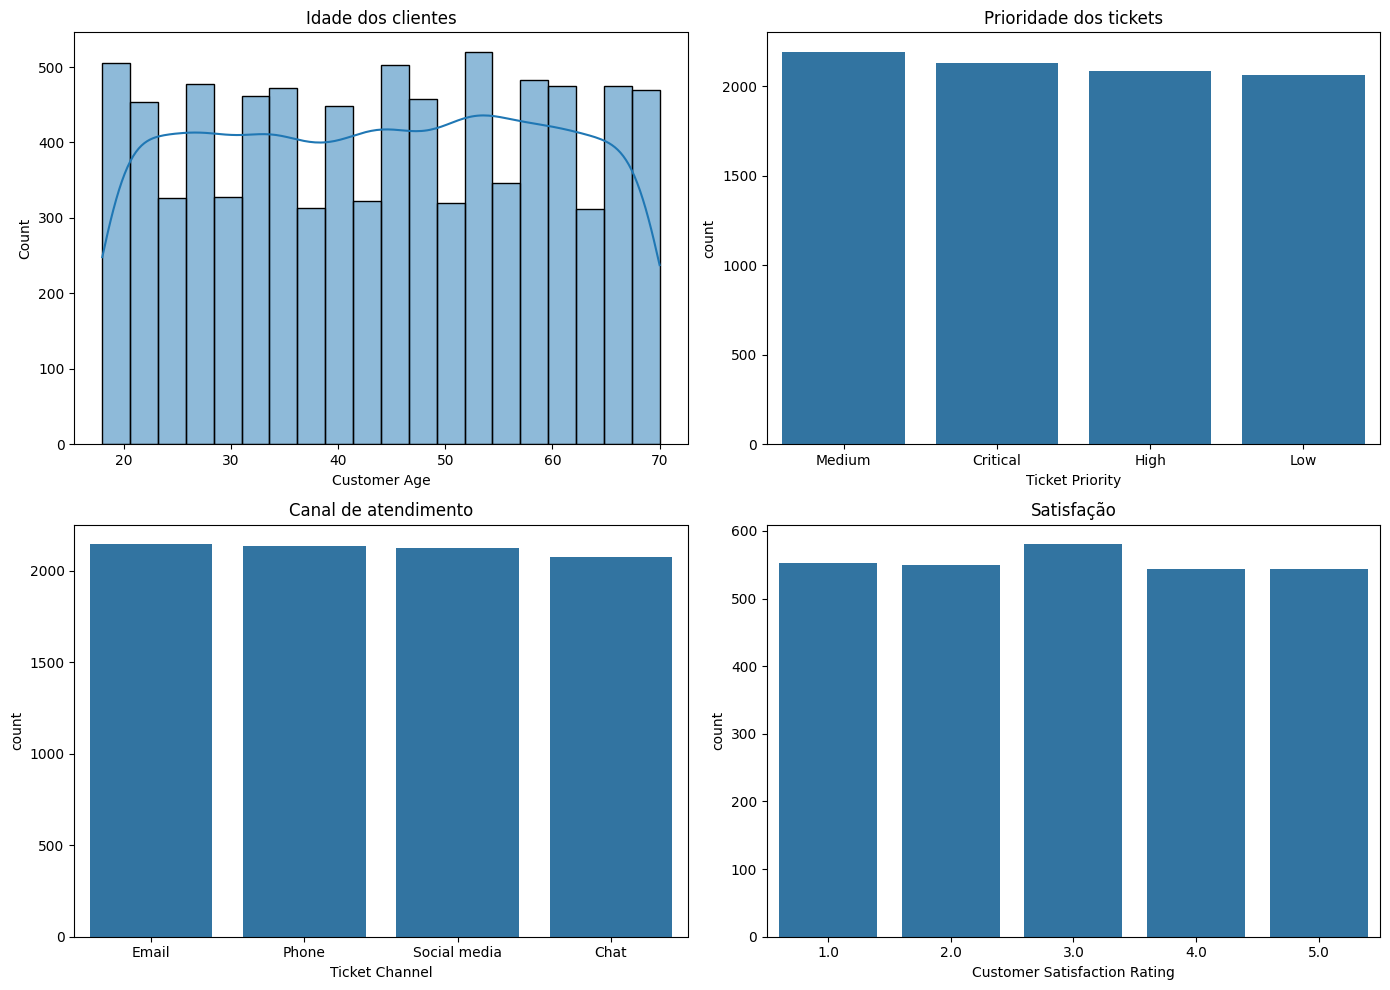

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df["Customer Age"], bins=20, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Idade dos clientes")

sns.countplot(
    data=df,
    x="Ticket Priority",
    order=df["Ticket Priority"].value_counts().index,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Prioridade dos tickets")

sns.countplot(
    data=df,
    x="Ticket Channel",
    order=df["Ticket Channel"].value_counts().index,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Canal de atendimento")

sns.countplot(
    data=df_satisfaction,
    x="Customer Satisfaction Rating",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Satisfação")

plt.tight_layout()
plt.show()

In [7]:
display(df["Ticket Subject"].value_counts().head(10))

Ticket Subject
Refund request           576
Software bug             574
Product compatibility    567
Delivery problem         561
Hardware issue           547
Battery life             542
Network problem          539
Installation support     530
Product setup            529
Payment issue            526
Name: count, dtype: int64

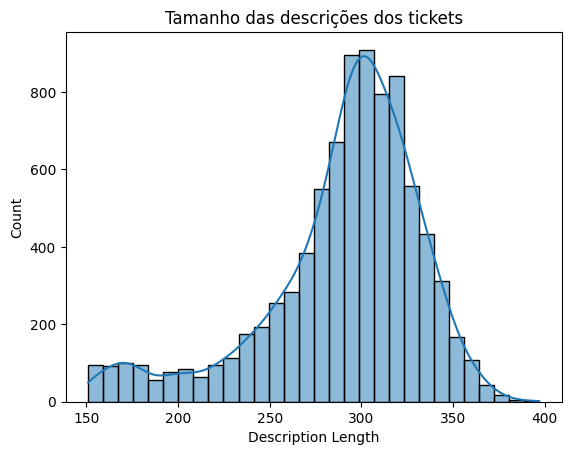

In [8]:
sns.histplot(df["Description Length"], bins=30, kde=True)
plt.title("Tamanho das descrições dos tickets")
plt.show()